### Inertial–vision fusion used for system identification (offline)

This notebook fuses high-rate IMU acceleration with lower-rate camera position to obtain drift-limited velocity and position estimates for system identification.

- **IMU path (high-frequency):** acceleration `a_rod` is bias-corrected and integrated to estimate velocity.
- **Camera path (low-frequency):** camera position is smoothed and differentiated to obtain an approximate velocity; camera position also anchors drift in the integrated estimate.
- **Complementary fusion:** IMU-based prediction is blended with camera-derived measurements using complementary filter weights (`alpha_fuse`, `alpha_pos`).

**Bias adaptation / ZUPT assumption:** Bias is updated only during intervals classified as *negligible motion*, and velocity is optionally forced to zero. This assumption is valid here because identification experiments were conducted with the mechanism mechanically supported (not handheld), so near-zero commanded velocity and near-zero camera velocity correspond to true rest. This logic should be disabled for handheld operation

Preset mm per pixel: 0.11254714285714287
True mm per pixel: 0.13745454545454547
Camera ratio: 1.2213063962806927
Mean dt: 0.01323557180851064
Sampling frequency (Hz): 75.55397035109488
Initial IMU accel bias (scaled): 0.010599999999999998
Stationary fraction: 0.0849933598937583
Any NaNs in v_fused? False
Any NaNs in x_fused_pos? False


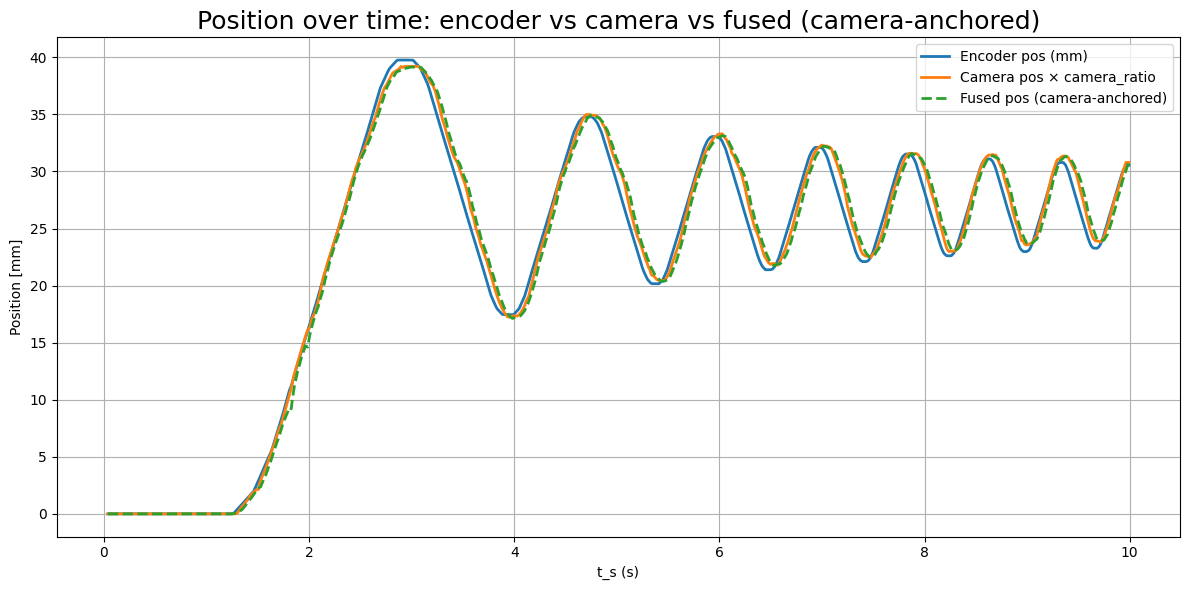

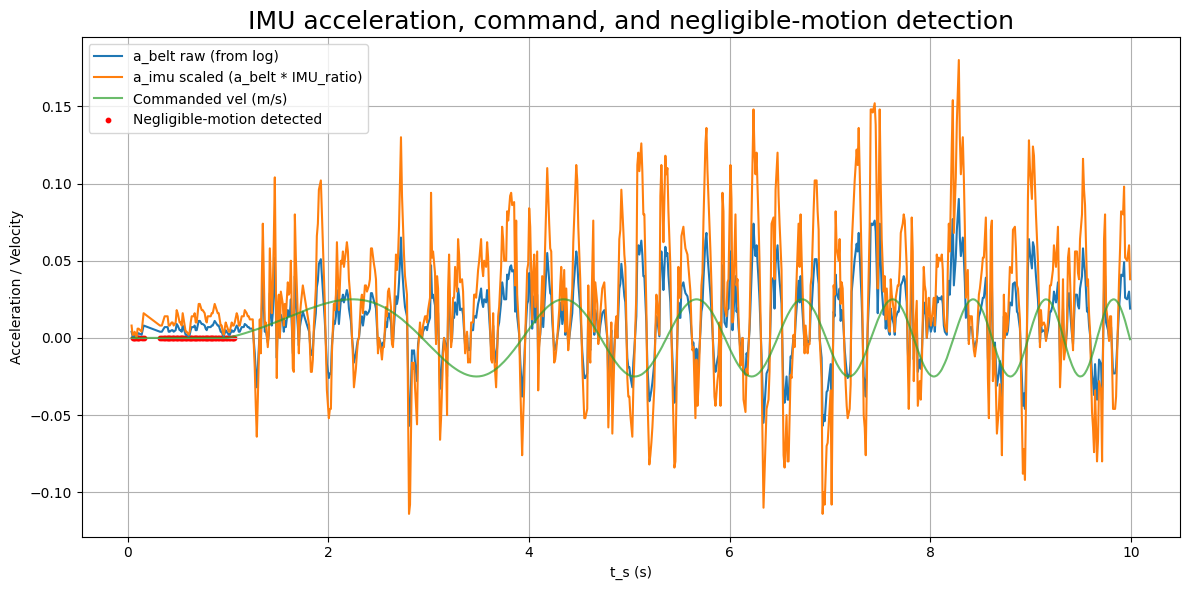

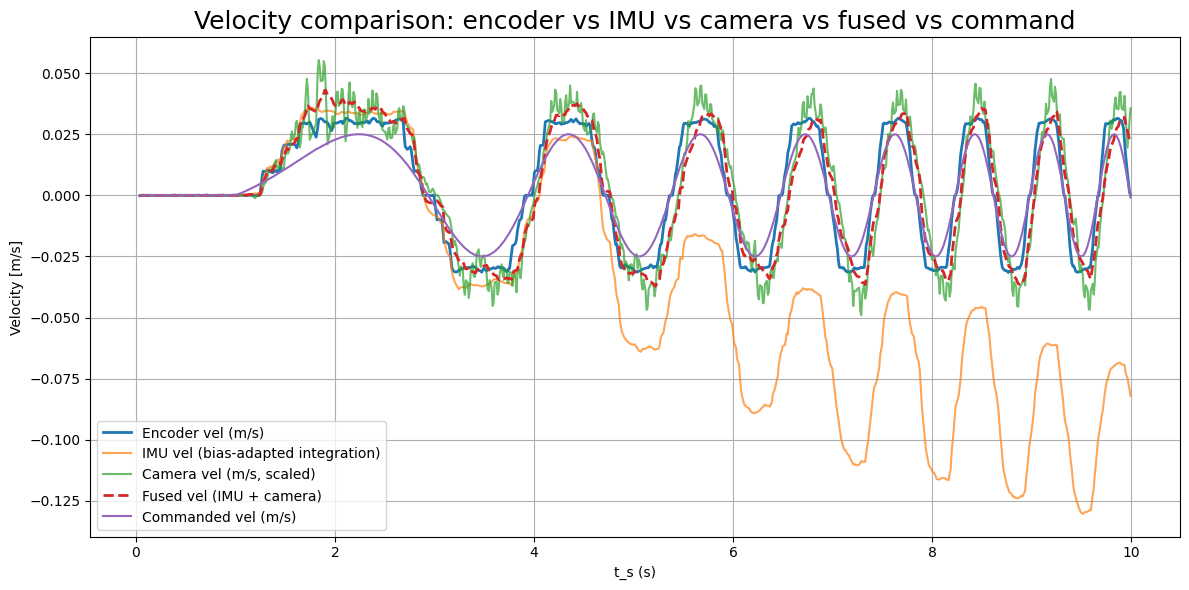

,t_s,enc_as5600_deg,acc_deg,a_belt,a_rod,v_belt,cmd_vel,cam_t_s,cam_x_mm,cam_dx_mm,...,v_imu_int,v_fused_m_s,x_fused_vel_m,x_fused_vel_mm,x_fused_m,x_fused_mm,stationary,a_belt_int,a_vel_int,imu_pos
0,0.03957,13.359,-0.088,0.004,0.010,0.000,0.0,0.019,0.00,0.00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,NaN,NaN,NaN
1,0.04963,13.447,0.000,0.001,0.010,0.000,0.0,0.019,0.00,0.00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,0.000046,NaN,0.000000
2,0.05985,13.447,0.000,0.001,0.008,0.000,0.0,0.031,0.00,0.00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,0.000082,6.557799e-07,0.000000
3,0.06990,13.447,0.000,0.002,0.010,0.000,0.0,0.046,0.00,0.00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,0.000118,1.663941e-06,0.000000
4,0.08949,13.359,-0.088,0.000,0.007,0.000,0.0,0.059,0.00,0.00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,0.000178,4.568648e-06,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,9.93284,102.744,-1350.703,0.049,-0.003,0.108,-1316.4,9.915,-0.60,0.00,...,-0.069478,0.032018,0.024106,24.106496,0.029276,29.275744,False,-0.034471,-1.716611e-01,-0.338352
749,9.94313,94.307,-1359.141,0.026,-0.135,0.108,-1102.1,9.915,-0.60,0.00,...,-0.072364,0.029511,0.024410,24.410163,0.029487,29.486844,False,-0.035237,-1.720197e-01,-0.339082
750,9.96308,81.650,-1371.797,0.025,-0.059,0.108,-619.4,9.939,-0.66,-0.05,...,-0.074926,0.026207,0.024933,24.932996,0.030053,30.052772,False,-0.037281,-1.727431e-01,-0.340551
751,9.98267,78.574,-1374.873,0.030,-0.105,0.109,-158.5,9.962,-0.76,-0.05,...,-0.079244,0.022704,0.025378,25.377766,0.030614,30.614179,False,-0.038993,-1.734902e-01,-0.342061


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter


############## Configuration #################

# Camera / geometry scaling
distance_from_wall = 0.18  # meters
resolution_x = 640
resolution_y = 480

f = 4.95               # focal length [mm]
pixel_size_mm = 0.0014 # pixel size [mm]
sensor_resolution_x = 4608 / 2  # pixels (binned/ROI or effective)
sensor_resolution_y = 2592 / 2  # pixels (binned/ROI or effective)

camera_mm_per_px_preset = 0.157566 / 1.4  # From preset calibratuion
camera_mm_per_px_y = (pixel_size_mm * distance_from_wall * 1000.0) / f * (sensor_resolution_y / resolution_y)
camera_ratio = (camera_mm_per_px_y / camera_mm_per_px_preset)

print("Preset mm per pixel:", camera_mm_per_px_preset)
print("True mm per pixel:", camera_mm_per_px_y)
print("Camera ratio:", camera_ratio)

# Dataset selection
response_data = {
    'Responses/Step/step_500_y.csv',
    'Responses/Step/step_2500_y.csv',
    'Responses/Impulse/impulse_2500_y.csv',
    'Responses/Chirp/chirp_0.1_5_2500_y.csv',
    'Responses/Random/random_y.csv',
}

# Pick one file to load
csv_path = 'Responses/Chirpchirp_0.1_5_2500_y.csv'  # <- ensure this path exists
df = pd.read_csv(csv_path)

# Testing window
df = df[df['t_s'] <= 10].reset_index(drop=True)

# Make input velocity 0 for first second
df.loc[df['t_s'] < 1.0, 'cmd_vel'] = 0.0

############### Quantize cmd_vel to actual driver speed (steps/s) ##############

ISR_TICK_HZ = 30000.0   # must match firmware
MAX_SPS     = 2500.0    # safety cap (same as firmware)

cmd = df['cmd_vel'].to_numpy(dtype=float)
sign = np.sign(cmd)
mag  = np.abs(cmd)

mag_clipped = np.clip(mag, 0.0, MAX_SPS)
nz = mag_clipped > 0.5

hpt_f = np.empty_like(mag_clipped)
hpt_f[nz] = ISR_TICK_HZ / (2.0 * mag_clipped[nz])
hpt_i = np.rint(hpt_f[nz]).astype(int)
hpt_i[hpt_i < 1] = 1

actual_sps = np.zeros_like(mag_clipped)
actual_sps[nz] = ISR_TICK_HZ / (2.0 * hpt_i)
actual_sps *= sign
df['cmd_vel_quant'] = -actual_sps

# Camera position aligned to main timebase

# Expects df contains cam_t_s and cam_y_mm
df['cam_pos_on_t_mm'] = camera_ratio * np.interp(df['t_s'], df['cam_t_s'], df['cam_y_mm'])

############## Time base and dt##############

signal_start_time = 1.0  # seconds
IMU_ratio         = 2.0  # IMU scale correction factor

df = df.sort_values('t_s').reset_index(drop=True)
df["dt"] = df["t_s"].diff().fillna(0.0)

mean_dt = df["dt"].iloc[1:].mean() if len(df) > 1 else np.nan
fs = (1.0 / mean_dt) if (mean_dt and mean_dt > 0) else np.nan
print("Mean dt:", mean_dt)
print("Sampling frequency (Hz):", fs)

t = df["t_s"].to_numpy()
dt = df["dt"].to_numpy()
N = len(df)

############## Camera smoothing & derivative #################

# Ensure odd window length <= N and >= polyorder+2
polyorder = 3
win = 21
if N < win:
    win = max(5, (N // 2) * 2 + 1)  # nearest odd <= N, at least 5
if win <= polyorder:
    win = polyorder + 2
    win = (win // 2) * 2 + 1  # make odd

df['cam_y_smooth'] = savgol_filter(df['cam_y_mm'], window_length=win, polyorder=polyorder)

# derivative wrt time (mm/s)
df['cam_deriv'] = -np.gradient(df['cam_y_smooth'], df['t_s'])

cam_deriv_clean = df['cam_deriv'].copy().interpolate(limit_direction='both').fillna(0.0)

# Camera velocity in m/s (scaled)
cam_v_m_s = -camera_ratio / 1000.0 * cam_deriv_clean.to_numpy()

# Camera position in m (scaled)
cam_pos_m_raw = camera_ratio * df['cam_y_mm'] / 1000.0
cam_pos_m = cam_pos_m_raw.interpolate(limit_direction='both').fillna(0.0).to_numpy()

############### Encoder-derived velocity/position (reference) ##############

STEPS_PER_REV  = 800.0  # TB6600 microstep setting
TRAVEL_PER_REV = 0.008  # lead screw pitch [m/rev] for y-axis

df['acc_deg_deriv'] = -np.gradient(df['acc_deg'], df['t_s'])     # deg/s
df['v_enc_m_s']     = df['acc_deg_deriv'] * TRAVEL_PER_REV / 360.0

df['enc_pos_m']  = -df['acc_deg'] * TRAVEL_PER_REV / 360.0
df['enc_pos_mm'] = df['enc_pos_m'] * 1000.0

# Commanded velocity in m/s (choose either quantized or raw)
df['v_cmd_m_s'] = -df['cmd_vel'] * (TRAVEL_PER_REV / STEPS_PER_REV)
# df['v_cmd_m_s'] = df['cmd_vel_quant'] * (TRAVEL_PER_REV / STEPS_PER_REV)


############### IMU acceleration: scale + initial bias estimate ##############

a_raw = df['a_rod'].to_numpy(dtype=float)
a_imu = IMU_ratio * a_raw

pre_mask = df['t_s'] < signal_start_time
a_bias0 = a_imu[pre_mask].mean() if pre_mask.sum() > 0 else 0.0
print("Initial IMU accel bias (scaled):", a_bias0)


############### Complementary fusion + (optional) ZUPT + adaptive bias ##############

# Fusion weights
alpha_fuse = 0.9  # IMU weight for velocity fusion (HF), camera is 1-alpha_fuse
alpha_pos  = 0.6  # prediction weight for position fusion, camera is 1-alpha_pos

# Bias adaptation rate (only updated when stationary)
BIAS_ALPHA = 0.01

# Stationary thresholds
CMD_THR   = 1e-3   # m/s
CAM_V_THR = 0.001  # m/s  (1 mm/s)
ENC_V_THR = 0.001  # m/s  (1 mm/s)
USE_ZUPT = True # Enable zero-velocity updates during stationary periods

# If encoder is unreliable at very low speeds
USE_ENCODER_IN_STATIONARY_GATE = True

v_imu       = np.zeros(N)   # IMU-only velocity (bias-corrected integration)
v_fused     = np.zeros(N)   # fused velocity
x_fused_vel = np.zeros(N)   # position from integrating fused velocity
x_fused_pos = np.zeros(N)   # position fused with camera anchor
a_bias_hat  = float(a_bias0)

# Initialize from camera (if finite)
v_fused[0]     = cam_v_m_s[0] if np.isfinite(cam_v_m_s[0]) else 0.0
x_fused_vel[0] = cam_pos_m[0] if np.isfinite(cam_pos_m[0]) else 0.0
x_fused_pos[0] = cam_pos_m[0] if np.isfinite(cam_pos_m[0]) else 0.0

stationary_mask = np.zeros(N, dtype=bool)

for i in range(1, N):
    dt_i = dt[i]
    if not np.isfinite(dt_i) or dt_i <= 0:
        dt_i = mean_dt if (np.isfinite(mean_dt) and mean_dt > 0) else 0.0

    # --- Stationary detection (ID-only assumption) ---
    if USE_ENCODER_IN_STATIONARY_GATE:
        is_stationary = (
            abs(df['v_cmd_m_s'].iloc[i]) < CMD_THR and
            abs(cam_v_m_s[i])            < CAM_V_THR and
            abs(df['v_enc_m_s'].iloc[i]) < ENC_V_THR
        )
    else:
        is_stationary = (
            abs(df['v_cmd_m_s'].iloc[i]) < CMD_THR and
            abs(cam_v_m_s[i])            < CAM_V_THR
        )

    stationary_mask[i] = is_stationary

    # --- Adaptive bias & acceleration used ---
    if is_stationary:
        # Update bias toward current accel measurement (assuming true accel ~ 0 at rest)
        a_bias_hat = (1.0 - BIAS_ALPHA) * a_bias_hat + BIAS_ALPHA * a_imu[i]
        a_used = 0.0
    else:
        a_used = a_imu[i] - a_bias_hat

    # --- IMU-only velocity integration ---
    v_imu[i] = v_imu[i-1] + a_used * dt_i

    # --- Prediction for fused velocity ---
    v_pred = v_fused[i-1] + a_used * dt_i

    # --- Camera measurement of velocity ---
    v_meas = cam_v_m_s[i]

    # --- Complementary fusion for velocity ---
    if np.isfinite(v_meas):
        v_fused[i] = alpha_fuse * v_pred + (1.0 - alpha_fuse) * v_meas
    else:
        v_fused[i] = v_pred

    # --- Optional ZUPT enforcement (only for supported ID experiments) ---
    if USE_ZUPT and is_stationary:
        v_imu[i]   = 0.0
        v_fused[i] = 0.0

    # --- Integrate fused velocity to intermediate position ---
    x_fused_vel[i] = x_fused_vel[i-1] + v_fused[i] * dt_i

    # --- Position fusion: prediction + camera anchor ---
    x_pred = x_fused_pos[i-1] + v_fused[i] * dt_i
    x_meas = cam_pos_m[i]

    if np.isfinite(x_meas):
        x_fused_pos[i] = alpha_pos * x_pred + (1.0 - alpha_pos) * x_meas
    else:
        x_fused_pos[i] = x_pred

df['v_imu_int']      = v_imu
df['v_fused_m_s']    = v_fused
df['x_fused_vel_m']  = x_fused_vel
df['x_fused_vel_mm'] = x_fused_vel * 1000.0
df['x_fused_m']      = x_fused_pos
df['x_fused_mm']     = x_fused_pos * 1000.0
df['stationary']     = stationary_mask

print("Stationary fraction:", stationary_mask.mean())
print("Any NaNs in v_fused?", np.isnan(v_fused).any())
print("Any NaNs in x_fused_pos?", np.isnan(x_fused_pos).any())

# ---------------------------------------
# Original IMU-only double integration (comparison)
# ---------------------------------------
acceleration_bias_start = df[df['t_s'] < signal_start_time]['a_belt'].mean() if (df['t_s'] < signal_start_time).any() else 0.0
a_belt_bias_corr = df['a_rod'] - acceleration_bias_start

df['a_belt_int'] = np.cumsum(
    (a_belt_bias_corr.shift(1) + a_belt_bias_corr) / 2 * df['t_s'].diff().fillna(0)
)
df['a_vel_int'] = np.cumsum(
    (df['a_belt_int'].shift(1) + df['a_belt_int']) / 2 * df['t_s'].diff().fillna(0)
)

df['imu_pos'] = np.cumsum(
    (df['v_imu_int'].shift(1) + df['v_imu_int']) / 2 * df['t_s'].diff().fillna(0)
)

############### FIGURE 1: position – encoder vs camera vs fused ##############
plt.figure(figsize=(12, 6))
plt.plot(df['t_s'], df['enc_pos_mm'], label='Encoder pos (mm)', linewidth=2)
plt.plot(df['t_s'], df['cam_pos_on_t_mm'], label='Camera pos × camera_ratio', linewidth=2)
plt.plot(df['t_s'], df['x_fused_mm'], label='Fused pos (camera-anchored)', linestyle='--', linewidth=2)
plt.title("Position over time: encoder vs camera vs fused (camera-anchored)", fontsize=18)
plt.xlabel("t_s (s)")
plt.ylabel("Position [mm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

############### FIGURE 2: accelerations & stationary periods ##############

plt.figure(figsize=(12, 6))
plt.plot(df['t_s'], df['a_belt'], label='a_belt raw (from log)')
plt.plot(df['t_s'], IMU_ratio * df['a_belt'], label='a_imu scaled (a_belt * IMU_ratio)')
plt.plot(df['t_s'], df['v_cmd_m_s'], label='Commanded vel (m/s)', alpha=0.7)
plt.scatter(df['t_s'][df['stationary']], np.zeros(df['stationary'].sum()),
            color='red', s=10, label='Negligible-motion detected')
plt.title("IMU acceleration, command, and negligible-motion detection", fontsize=18)
plt.xlabel("t_s (s)")
plt.ylabel("Acceleration / Velocity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

############### FIGURE 3: velocities – encoder vs IMU-only vs camera vs fused vs command ##############

plt.figure(figsize=(12, 6))
plt.plot(df['t_s'], df['v_enc_m_s'], label='Encoder vel (m/s)', linewidth=2)
plt.plot(df['t_s'], df['v_imu_int'], label='IMU vel (bias-adapted integration)', alpha=0.7)
plt.plot(df['t_s'], cam_v_m_s, label='Camera vel (m/s, scaled)', alpha=0.7)
plt.plot(df['t_s'], df['v_fused_m_s'], label='Fused vel (IMU + camera)', linestyle='--', linewidth=2)
plt.plot(df['t_s'], df['v_cmd_m_s'], label='Commanded vel (m/s)', alpha=1)
plt.title("Velocity comparison: encoder vs IMU vs camera vs fused vs command", fontsize=18)
plt.xlabel("t_s (s)")
plt.ylabel("Velocity [m/s]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

drop_cols = [
    'clar_counts', 'clar_deg', 'axW', 'ayW', 'azW',
    'cmd_sps', 'cmd_dir',
    'cam_y_mm', 'cam_dy_mm',
]
existing_drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=existing_drop_cols, inplace=True)

display(df)